# __Main_part__

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from collections import Counter, defaultdict
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset

## __Task_1 - Introduction__

Вопросы: \
а. Опишите типы задач, для которых полезны рекуррентные нейронные сети. \
б. Приведите два примера формулировок задачи «один ко многим», «многие ко многим» и «многие к одному». \
в. Представьте, что у вас есть рекуррентная нейронная сеть (RNN), классифицирующая язык входящих слов. Проиллюстрируйте (в Paint, Drawio и т. д.) с помощью блоков, как эта модель будет обрабатывать слово «Hello». Нарисуйте каждый вход и выход. Определите каждый блок с его параметрами. Проиллюстрируйте начальное значение скрытого состояния. \
г. Объясните основное различие между обычными RNN, LSTM и GRU. Нарисуйте LSTM или GRU, аналогичные RNN. \

Ответы: \
а. Рекуррентные сети могут быть использованы в задачах связанных с предсказанием цены акций, где у нас имеется фича с изменением цены акции в течение времени. Также в задачах с переводом, где нужно понимать последовательность слов чтобы уловить общий смысл.\
б. Один ко многим - напрример, генерация текста по заданному слову, или генерация мелодии по одной ноте. \
Многие к одному - например, задача анализа тональности (по тексту выдается метка + или -), или прогноз цены акции. \
Многие ко многим - распознавание речи, машинный перевод. \
в. См картинку ниже\
г. Основное различие между RNN и LSTM и GRU в том что RNN может со временем забывать старые входы (проблема затухающего градиента), т.е. хорошо видит только если последовательность небольшая. В LSTM добавлена специальные ячейки памяти, GRU - упрощеннная версия LSTM (среднее между LSTM и RNN).

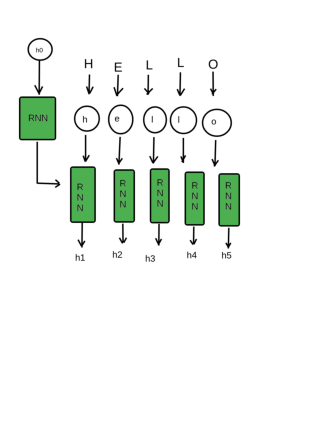

In [4]:
img = mpimg.imread("drive/MyDrive/Colab_Notebooks/s21_ML10/1.png")
plt.figure(figsize=(4, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

## __Task_2 - Data Analysis__

In [5]:
df = pd.read_csv("drive/MyDrive/Colab_Notebooks/s21_ML10/data/babynames-clean.csv")

In [6]:
print(df.shape)
df.sample(5)

(6781, 2)


,John,boy
1502,Terrence,boy
2737,Dominique,boy
4223,Veda,girl
1377,Oakley,boy
5838,Liliana,girl


In [7]:
df = df.rename(columns={"John": "Name", "boy": "Gender"})

In [8]:
df["name_length"] = df["Name"].apply(len)
df.head()

,Name,Gender,name_length
0,William,boy,7
1,James,boy,5
2,Charles,boy,7
3,George,boy,6
4,Frank,boy,5


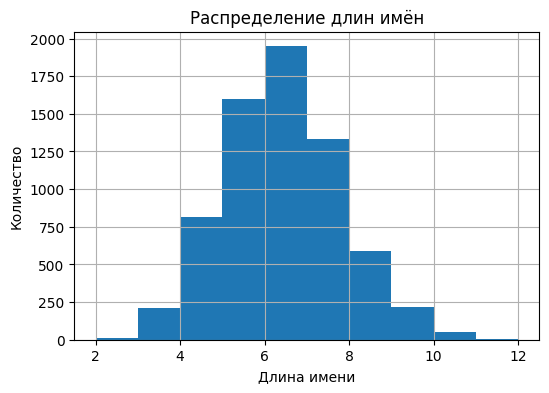

In [9]:
df["name_length"].hist(bins=range(df["name_length"].min(), df["name_length"].max() + 2), figsize=(6, 4))

plt.xlabel("Длина имени")
plt.ylabel("Количество")
plt.title("Распределение длин имён")
plt.show()

In [10]:
df['Gender'].value_counts()

,count
Gender,
boy,3436
girl,3345


In [11]:
letters_series = df["Name"].str.lower().str.cat()
freq_series = pd.Series(list(letters_series)).value_counts()
print(freq_series)

a    5593
e    5038
n    3523
i    3264
l    3255
r    3070
o    2070
t    1745
s    1674
d    1532
m    1245
y    1243
h    1205
c    1063
u     707
b     673
k     616
g     526
j     501
v     490
f     302
w     271
p     265
z     199
x      71
q      61
Name: count, dtype: int64


## __Task_3 - Data preparation__

In [12]:
df_encoded = pd.get_dummies(df, columns=["Gender"], prefix="", prefix_sep="")
df_encoded["boy"] = df_encoded["boy"].astype(int)
df_encoded["girl"] = df_encoded["girl"].astype(int)
df_encoded.sample(5)

,Name,name_length,boy,girl
2885,Devan,5,1,0
2369,Rolando,7,1,0
5654,Bethann,7,0,1
223,Byron,5,1,0
5801,Angelic,7,0,1


In [13]:
df_encoded["Name"] = df_encoded["Name"].str.lower()
df_encoded.head()

,Name,name_length,boy,girl
0,william,7,1,0
1,james,5,1,0
2,charles,7,1,0
3,george,6,1,0
4,frank,5,1,0


In [14]:
df_encoded["ProcessedName"] = "<SOS>" + df_encoded["Name"] + "<EOS>"
max_len = df_encoded["ProcessedName"].str.len().max() # 21
df_encoded["ProcessedName"] = df_encoded["ProcessedName"].str.pad(width=max_len, side="right", fillchar=" ")
df_encoded.head()

,Name,name_length,boy,girl,ProcessedName
0,william,7,1,0,<SOS>william<EOS>
1,james,5,1,0,<SOS>james<EOS>
2,charles,7,1,0,<SOS>charles<EOS>
3,george,6,1,0,<SOS>george<EOS>
4,frank,5,1,0,<SOS>frank<EOS>


In [15]:
tokens = set("".join(df_encoded["ProcessedName"]))
tokens.update(["<SOS>", "<EOS>", " "])

tokens = sorted(tokens)
tokens = [tok for tok in tokens if tok not in {"<", ">", "S", "O", "E"}]
token2id = {token: idx for idx, token in enumerate(tokens)}
id2token = {idx: token for token, idx in token2id.items()}

token2id

{' ': 0,
 '<EOS>': 1,
 '<SOS>': 2,
 'a': 3,
 'b': 4,
 'c': 5,
 'd': 6,
 'e': 7,
 'f': 8,
 'g': 9,
 'h': 10,
 'i': 11,
 'j': 12,
 'k': 13,
 'l': 14,
 'm': 15,
 'n': 16,
 'o': 17,
 'p': 18,
 'q': 19,
 'r': 20,
 's': 21,
 't': 22,
 'u': 23,
 'v': 24,
 'w': 25,
 'x': 26,
 'y': 27,
 'z': 28}

In [16]:
def tokenize_name(name):
  tokens = []
  i = 0
  while i < len(name):
    if name[i:i+5] == "<SOS>":
      tokens.append("<SOS>")
      i += 5
    elif name[i:i+5] == "<EOS>":
      tokens.append("<EOS>")
      i += 5
    else:
      tokens.append(name[i])
      i += 1
  return tokens

def encode_name(name, token2id, max_len=13):
  tokens = tokenize_name(name)
  seq = [token2id[tok] for tok in tokens]
  if len(seq) < max_len: seq += [token2id[" "]] * (max_len - len(seq))
  else: seq = seq[:max_len]
  return seq

In [17]:
names = df_encoded["ProcessedName"]
sequences = np.array([encode_name(name, token2id, max_len) for name in names])

print(f"Shape of sequences:  {sequences.shape}")
print(f"First example:       {sequences[0]}")

Shape of sequences:  (6781, 21)
First example:       [ 2 25 11 14 14 11  3 15  1  0  0  0  0  0  0  0  0  0  0  0  0]


In [18]:
X_train, X_temp, y_train, y_temp = train_test_split(
    sequences, df_encoded['boy'], test_size=0.2, random_state=42, shuffle=True
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, shuffle=True
)

print(f"Train shape:      {X_train.shape}, {y_train.shape}")
print(f"Validation shape: {X_val.shape}, {y_val.shape}")
print(f"Test shape:       {X_test.shape}, {y_test.shape}")

Train shape:      (5424, 21), (5424,)
Validation shape: (678, 21), (678,)
Test shape:       (679, 21), (679,)


## __Task_4 - Vanilla RNN__

In [19]:
X_train = torch.tensor(X_train, dtype=torch.long)
X_val = torch.tensor(X_val, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.long)

In [20]:
class VanillaRNN(nn.Module):
  def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim=1, dropout=0.3):
    super().__init__()
    self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
    self.dropout = nn.Dropout(dropout)

    self.hidden_dim = hidden_dim
    self.Wxh = nn.Parameter(torch.randn(embedding_dim, hidden_dim) * 0.01)
    self.Whh = nn.Parameter(torch.randn(hidden_dim, hidden_dim) * 0.01)
    self.bh = nn.Parameter(torch.zeros(hidden_dim))

    self.fc_token = nn.Linear(hidden_dim, vocab_size)

    self.fc_gender = nn.Linear(hidden_dim, output_dim)

  def init_hidden(self, batch_size, device=None):
    h0 = torch.zeros(batch_size, self.hidden_dim)
    if device: h0 = h0.to(device)
    return h0

  def forward(self, x, h0=None):
    batch_size, seq_len = x.size()
    if h0 is None:
      h0 = self.init_hidden(batch_size, device=x.device)

    embedded = self.embedding(x)
    embedded = self.dropout(embedded)

    h = h0
    outputs = []
    for t in range(seq_len):
      xt = embedded[:, t, :]
      h = torch.tanh(xt @ self.Wxh + h @ self.Whh + self.bh)
      h = self.dropout(h)
      outputs.append(h.unsqueeze(1))

    h_seq = torch.cat(outputs, dim=1)
    token_logits = self.fc_token(h_seq)
    gender_logit = self.fc_gender(h_seq[:, -1, :])
    gender_prob = torch.sigmoid(gender_logit)

    return token_logits, gender_prob, h_seq

In [ ]:
train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.long),
                              torch.tensor(y_train.values, dtype=torch.float))

val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.long),
                            torch.tensor(y_val.values, dtype=torch.float))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32)

vocab_size = len(token2id)
embedding_dim = 512
hidden_dim = 1024
device = "cuda" if torch.cuda.is_available() else "cpu"

rnn_model = VanillaRNN(vocab_size, embedding_dim, hidden_dim).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(rnn_model.parameters(), lr=1e-5)

In [ ]:
train_losses, val_losses = [], []

for epoch in range(500):
  rnn_model.train()
  train_loss, train_correct, train_total = 0, 0, 0

  for batch in train_loader:
    batch = batch[0].to(device)
    token_logits, _, _ = rnn_model(batch)
    logits = token_logits[:, :-1, :]
    targets = batch[:, 1:]
    logits = logits.reshape(-1, logits.size(-1))
    targets = targets.reshape(-1)
    loss = criterion(logits, targets)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    train_loss += loss.item()
    preds = logits.argmax(dim=-1)
    train_correct += (preds == targets).sum().item()
    train_total += targets.numel()

  train_loss /= len(train_loader)
  train_acc = train_correct / train_total

  rnn_model.eval()
  val_loss, val_correct, val_total = 0, 0, 0
  with torch.no_grad():
    for batch in val_loader:
      batch = batch[0].to(device)
      token_logits, _, _ = rnn_model(batch)
      logits = token_logits[:, :-1, :]
      targets = batch[:, 1:]
      logits = logits.reshape(-1, logits.size(-1))
      targets = targets.reshape(-1)
      loss = criterion(logits, targets)
      val_loss += loss.item()
      preds = logits.argmax(dim=-1)
      val_correct += (preds == targets).sum().item()
      val_total += targets.numel()

  val_loss /= len(val_loader)
  val_acc = val_correct / val_total

  train_losses.append(train_loss)
  val_losses.append(val_loss)

  print(f"Epoch {epoch+1:02d}:    "
        f"Train_Loss={train_loss:.4f}, Train_Acc={train_acc:.4f}    "
        f"Val_Loss={val_loss:.4f}, Val_Acc={val_acc:.4f}")

Epoch 01:    Train_Loss=2.1382, Train_Acc=0.5446    Val_Loss=1.0082, Val_Acc=0.7212
Epoch 02:    Train_Loss=0.9664, Train_Acc=0.7272    Val_Loss=0.8899, Val_Acc=0.7367
Epoch 03:    Train_Loss=0.8812, Train_Acc=0.7403    Val_Loss=0.8408, Val_Acc=0.7479
Epoch 04:    Train_Loss=0.8454, Train_Acc=0.7452    Val_Loss=0.8169, Val_Acc=0.7517
Epoch 05:    Train_Loss=0.8249, Train_Acc=0.7489    Val_Loss=0.8029, Val_Acc=0.7554
Epoch 06:    Train_Loss=0.8135, Train_Acc=0.7505    Val_Loss=0.7940, Val_Acc=0.7566
Epoch 07:    Train_Loss=0.8052, Train_Acc=0.7508    Val_Loss=0.7881, Val_Acc=0.7561
Epoch 08:    Train_Loss=0.7997, Train_Acc=0.7522    Val_Loss=0.7824, Val_Acc=0.7577
Epoch 09:    Train_Loss=0.7936, Train_Acc=0.7528    Val_Loss=0.7783, Val_Acc=0.7572
Epoch 10:    Train_Loss=0.7899, Train_Acc=0.7532    Val_Loss=0.7748, Val_Acc=0.7591
Epoch 11:    Train_Loss=0.7852, Train_Acc=0.7540    Val_Loss=0.7719, Val_Acc=0.7600
Epoch 12:    Train_Loss=0.7835, Train_Acc=0.7544    Val_Loss=0.7690, Val_Acc

In [ ]:
def generate_name(model, token2id, id2token, max_len=20, t=1.0, device=device):
    model.eval()
    model.to(device)

    input_seq = torch.tensor([[token2id["<SOS>"]]], dtype=torch.long, device=device)
    generated_tokens = []

    with torch.no_grad():
        for _ in range(max_len):
            out = model(input_seq)
            token_logits = out[0]
            logits = token_logits[:, -1, :]
            probs = F.softmax(logits / t, dim=-1)
            next_token_id = torch.multinomial(probs, num_samples=1).item()
            if next_token_id == token2id["<EOS>"]:
                break
            generated_tokens.append(id2token[next_token_id])
            input_seq = torch.cat([input_seq, torch.tensor([[next_token_id]], device=device)], dim=1)

    return "".join(generated_tokens)

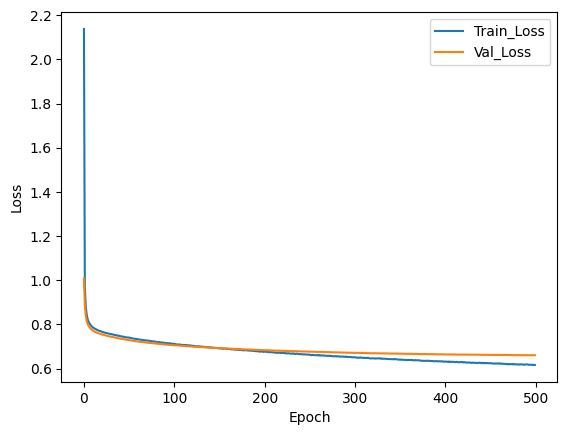

In [ ]:
plt.plot(train_losses, label="Train_Loss")
plt.plot(val_losses, label="Val_Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
rnn_model.eval()
for i in range(10):
  print(generate_name(rnn_model, token2id, id2token, t=0.5))

danie
dellie
marcille
della
linda
leonar
eliana
jaquell
oren
charlee


In [ ]:
y_true, y_pred = [], []

rnn_model.eval()
with torch.no_grad():
  for i in range(0, len(X_val), 32):
    X_batch = torch.tensor(X_val[i:i+32], dtype=torch.long).to(device)
    _, gender_prob, _ = rnn_model(X_batch)

    y_pred.append(gender_prob.cpu())
    y_true.append(torch.tensor(y_val.iloc[i:i+32].to_numpy(), dtype=torch.float32))

y_pred = torch.cat(y_pred).numpy()
y_true = torch.cat(y_true).numpy()

roc_auc = roc_auc_score(y_true, y_pred)
print(f"ROC AUC on val set: {roc_auc:.4f}")

ROC AUC on val set: 0.3789


## __Task_5 - Vanilla GRU__

In [21]:
class VanillaGRU(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim=1, dropout_p=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        self.hidden_dim = hidden_dim
        self.dropout = nn.Dropout(dropout_p)

        self.Wxz = nn.Parameter(torch.randn(embedding_dim, hidden_dim) * 0.01)
        self.Whz = nn.Parameter(torch.randn(hidden_dim, hidden_dim) * 0.01)
        self.bz  = nn.Parameter(torch.zeros(hidden_dim))

        self.Wxr = nn.Parameter(torch.randn(embedding_dim, hidden_dim) * 0.01)
        self.Whr = nn.Parameter(torch.randn(hidden_dim, hidden_dim) * 0.01)
        self.br  = nn.Parameter(torch.zeros(hidden_dim))

        self.Wxh = nn.Parameter(torch.randn(embedding_dim, hidden_dim) * 0.01)
        self.Whh = nn.Parameter(torch.randn(hidden_dim, hidden_dim) * 0.01)
        self.bh  = nn.Parameter(torch.zeros(hidden_dim))

        self.fc_token = nn.Linear(hidden_dim, vocab_size)
        self.fc_gender = nn.Linear(hidden_dim, output_dim)

    def init_hidden(self, batch_size, device=None):
        h0 = torch.zeros(batch_size, self.hidden_dim)
        if device:
            h0 = h0.to(device)
        return h0

    def forward(self, x, h0=None):
        batch_size, seq_len = x.size()
        if h0 is None:
            h0 = self.init_hidden(batch_size, device=x.device)

        embedded = self.dropout(self.embedding(x))

        h = h0
        outputs = []
        for t in range(seq_len):
            xt = embedded[:, t, :]

            zt = torch.sigmoid(xt @ self.Wxz + h @ self.Whz + self.bz)
            rt = torch.sigmoid(xt @ self.Wxr + h @ self.Whr + self.br)
            h_tilde = torch.tanh(xt @ self.Wxh + (rt * h) @ self.Whh + self.bh)
            h = (1 - zt) * h + zt * h_tilde

            outputs.append(h.unsqueeze(1))

        h_seq = torch.cat(outputs, dim=1)
        h_seq = self.dropout(h_seq)

        token_logits = self.fc_token(h_seq)
        gender_logit = self.fc_gender(h_seq[:, -1, :])
        gender_prob = torch.sigmoid(gender_logit)

        return token_logits, gender_prob, h_seq

In [ ]:
train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.long),
                              torch.tensor(y_train.values, dtype=torch.float))

val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.long),
                            torch.tensor(y_val.values, dtype=torch.float))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32)

vocab_size = len(token2id)
embedding_dim = 512
hidden_dim = 1024
device = "cuda" if torch.cuda.is_available() else "cpu"

gru_model = VanillaGRU(vocab_size, embedding_dim, hidden_dim).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(gru_model.parameters(), lr=1e-5)

In [ ]:
train_losses, val_losses = [], []

for epoch in range(200):
  gru_model.train()
  train_loss, train_correct, train_total = 0, 0, 0

  for batch in train_loader:
    batch = batch[0].to(device)
    token_logits, _, _ = gru_model(batch)
    logits = token_logits[:, :-1, :]
    targets = batch[:, 1:]
    logits = logits.reshape(-1, logits.size(-1))
    targets = targets.reshape(-1)
    loss = criterion(logits, targets)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    train_loss += loss.item()
    preds = logits.argmax(dim=-1)
    train_correct += (preds == targets).sum().item()
    train_total += targets.numel()

  train_loss /= len(train_loader)
  train_acc = train_correct / train_total

  gru_model.eval()
  val_loss, val_correct, val_total = 0, 0, 0
  with torch.no_grad():
    for batch in val_loader:
      batch = batch[0].to(device)
      token_logits, _, _ = gru_model(batch)
      logits = token_logits[:, :-1, :]
      targets = batch[:, 1:]
      logits = logits.reshape(-1, logits.size(-1))
      targets = targets.reshape(-1)
      loss = criterion(logits, targets)
      val_loss += loss.item()
      preds = logits.argmax(dim=-1)
      val_correct += (preds == targets).sum().item()
      val_total += targets.numel()

  val_loss /= len(val_loader)
  val_acc = val_correct / val_total

  train_losses.append(train_loss)
  val_losses.append(val_loss)

  print(f"Epoch {epoch+1:02d}:    "
        f"Train_Loss={train_loss:.4f}, Train_Acc={train_acc:.4f}    "
        f"Val_Loss={val_loss:.4f}, Val_Acc={val_acc:.4f}")

Epoch 01:    Train_Loss=2.4025, Train_Acc=0.5865    Val_Loss=1.0501, Val_Acc=0.6844
Epoch 02:    Train_Loss=1.0051, Train_Acc=0.7144    Val_Loss=0.9386, Val_Acc=0.7327
Epoch 03:    Train_Loss=0.9241, Train_Acc=0.7349    Val_Loss=0.8827, Val_Acc=0.7438
Epoch 04:    Train_Loss=0.8791, Train_Acc=0.7425    Val_Loss=0.8505, Val_Acc=0.7486
Epoch 05:    Train_Loss=0.8514, Train_Acc=0.7457    Val_Loss=0.8298, Val_Acc=0.7514
Epoch 06:    Train_Loss=0.8335, Train_Acc=0.7475    Val_Loss=0.8155, Val_Acc=0.7524
Epoch 07:    Train_Loss=0.8206, Train_Acc=0.7492    Val_Loss=0.8052, Val_Acc=0.7539
Epoch 08:    Train_Loss=0.8110, Train_Acc=0.7497    Val_Loss=0.7972, Val_Acc=0.7550
Epoch 09:    Train_Loss=0.8032, Train_Acc=0.7507    Val_Loss=0.7906, Val_Acc=0.7555
Epoch 10:    Train_Loss=0.7974, Train_Acc=0.7522    Val_Loss=0.7851, Val_Acc=0.7556
Epoch 11:    Train_Loss=0.7924, Train_Acc=0.7524    Val_Loss=0.7805, Val_Acc=0.7556
Epoch 12:    Train_Loss=0.7867, Train_Acc=0.7533    Val_Loss=0.7764, Val_Acc

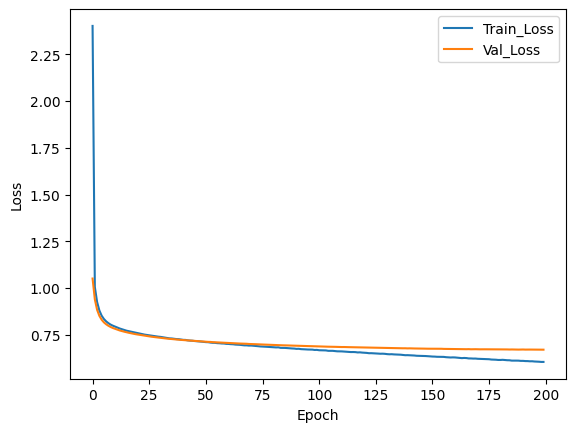

In [ ]:
plt.plot(train_losses, label="Train_Loss")
plt.plot(val_losses, label="Val_Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
gru_model.eval()
for i in range(10):
  print(generate_name(gru_model, token2id, id2token, t=0.5))

destan
delia
alexandra
arlena
sterra
darry
denard
belly
linda
corina


In [ ]:
y_true, y_pred = [], []

gru_model.eval()
with torch.no_grad():
  for i in range(0, len(X_val), 32):
    X_batch = torch.tensor(X_val[i:i+32], dtype=torch.long).to(device)
    _, gender_prob, _ = gru_model(X_batch)

    y_pred.append(gender_prob.cpu())
    y_true.append(torch.tensor(y_val.iloc[i:i+32].to_numpy(), dtype=torch.float32))

y_pred = torch.cat(y_pred).numpy()
y_true = torch.cat(y_true).numpy()

roc_auc = roc_auc_score(y_true, y_pred)
print(f"ROC AUC on val set: {roc_auc:.4f}")

ROC AUC on val set: 0.4906


## __Task_6 - Vanilla LSTM__

In [22]:
class VanillaLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim=1, dropout_p=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.hidden_dim = hidden_dim

        self.Wxi = nn.Parameter(torch.randn(embedding_dim, hidden_dim) * 0.01)
        self.Whi = nn.Parameter(torch.randn(hidden_dim, hidden_dim) * 0.01)
        self.bi  = nn.Parameter(torch.zeros(hidden_dim))

        self.Wxf = nn.Parameter(torch.randn(embedding_dim, hidden_dim) * 0.01)
        self.Whf = nn.Parameter(torch.randn(hidden_dim, hidden_dim) * 0.01)
        self.bf  = nn.Parameter(torch.zeros(hidden_dim))

        self.Wxo = nn.Parameter(torch.randn(embedding_dim, hidden_dim) * 0.01)
        self.Who = nn.Parameter(torch.randn(hidden_dim, hidden_dim) * 0.01)
        self.bo  = nn.Parameter(torch.zeros(hidden_dim))

        self.Wxc = nn.Parameter(torch.randn(embedding_dim, hidden_dim) * 0.01)
        self.Whc = nn.Parameter(torch.randn(hidden_dim, hidden_dim) * 0.01)
        self.bc  = nn.Parameter(torch.zeros(hidden_dim))

        self.dropout = nn.Dropout(dropout_p)

        self.fc_token = nn.Linear(hidden_dim, vocab_size)
        self.fc_gender = nn.Linear(hidden_dim, output_dim)

    def init_hidden(self, batch_size, device=None):
        h0 = torch.zeros(batch_size, self.hidden_dim)
        c0 = torch.zeros(batch_size, self.hidden_dim)
        if device:
            h0, c0 = h0.to(device), c0.to(device)
        return h0, c0

    def forward(self, x, h0=None, c0=None):
        batch_size, seq_len = x.size()

        if h0 is None or c0 is None:
            h, c = self.init_hidden(batch_size, device=x.device)
        else:
            h, c = h0, c0

        embedded = self.dropout(self.embedding(x))
        outputs = []

        for t in range(seq_len):
            xt = embedded[:, t, :]

            i_t = torch.sigmoid(xt @ self.Wxi + h @ self.Whi + self.bi)
            f_t = torch.sigmoid(xt @ self.Wxf + h @ self.Whf + self.bf)
            o_t = torch.sigmoid(xt @ self.Wxo + h @ self.Who + self.bo)
            g_t = torch.tanh(xt @ self.Wxc + h @ self.Whc + self.bc)

            c = f_t * c + i_t * g_t
            h = o_t * torch.tanh(c)

            outputs.append(h.unsqueeze(1))

        h_seq = torch.cat(outputs, dim=1)
        h_seq = self.dropout(h_seq)

        token_logits = self.fc_token(h_seq)
        gender_logit = self.fc_gender(h_seq[:, -1, :])
        gender_prob = torch.sigmoid(gender_logit)

        return token_logits, gender_prob, h_seq

In [ ]:
train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.long),
                              torch.tensor(y_train.values, dtype=torch.float))

val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.long),
                            torch.tensor(y_val.values, dtype=torch.float))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32)

vocab_size = len(token2id)
embedding_dim = 512
hidden_dim = 1024
device = "cuda" if torch.cuda.is_available() else "cpu"

lstm_model = VanillaLSTM(vocab_size, embedding_dim, hidden_dim).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(lstm_model.parameters(), lr=1e-5)

In [ ]:
train_losses, val_losses = [], []

for epoch in range(200):
  lstm_model.train()
  train_loss, train_correct, train_total = 0, 0, 0

  for batch in train_loader:
    batch = batch[0].to(device)
    token_logits, _, _ = lstm_model(batch)
    logits = token_logits[:, :-1, :]
    targets = batch[:, 1:]
    logits = logits.reshape(-1, logits.size(-1))
    targets = targets.reshape(-1)
    loss = criterion(logits, targets)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    train_loss += loss.item()
    preds = logits.argmax(dim=-1)
    train_correct += (preds == targets).sum().item()
    train_total += targets.numel()

  train_loss /= len(train_loader)
  train_acc = train_correct / train_total

  lstm_model.eval()
  val_loss, val_correct, val_total = 0, 0, 0
  with torch.no_grad():
    for batch in val_loader:
      batch = batch[0].to(device)
      token_logits, _, _ = lstm_model(batch)
      logits = token_logits[:, :-1, :]
      targets = batch[:, 1:]
      logits = logits.reshape(-1, logits.size(-1))
      targets = targets.reshape(-1)
      loss = criterion(logits, targets)
      val_loss += loss.item()
      preds = logits.argmax(dim=-1)
      val_correct += (preds == targets).sum().item()
      val_total += targets.numel()

  val_loss /= len(val_loader)
  val_acc = val_correct / val_total

  train_losses.append(train_loss)
  val_losses.append(val_loss)

  print(f"Epoch {epoch+1:02d}:    "
        f"Train_Loss={train_loss:.4f}, Train_Acc={train_acc:.4f}    "
        f"Val_Loss={val_loss:.4f}, Val_Acc={val_acc:.4f}")

Epoch 01:    Train_Loss=2.4693, Train_Acc=0.5275    Val_Loss=1.1178, Val_Acc=0.6745
Epoch 02:    Train_Loss=1.0774, Train_Acc=0.6881    Val_Loss=1.0031, Val_Acc=0.7176
Epoch 03:    Train_Loss=0.9783, Train_Acc=0.7236    Val_Loss=0.9273, Val_Acc=0.7356
Epoch 04:    Train_Loss=0.9200, Train_Acc=0.7367    Val_Loss=0.8867, Val_Acc=0.7445
Epoch 05:    Train_Loss=0.8856, Train_Acc=0.7441    Val_Loss=0.8604, Val_Acc=0.7485
Epoch 06:    Train_Loss=0.8617, Train_Acc=0.7464    Val_Loss=0.8421, Val_Acc=0.7503
Epoch 07:    Train_Loss=0.8454, Train_Acc=0.7477    Val_Loss=0.8285, Val_Acc=0.7521
Epoch 08:    Train_Loss=0.8326, Train_Acc=0.7486    Val_Loss=0.8175, Val_Acc=0.7521
Epoch 09:    Train_Loss=0.8222, Train_Acc=0.7491    Val_Loss=0.8089, Val_Acc=0.7534
Epoch 10:    Train_Loss=0.8132, Train_Acc=0.7508    Val_Loss=0.8013, Val_Acc=0.7544
Epoch 11:    Train_Loss=0.8062, Train_Acc=0.7509    Val_Loss=0.7948, Val_Acc=0.7560
Epoch 12:    Train_Loss=0.7995, Train_Acc=0.7524    Val_Loss=0.7893, Val_Acc

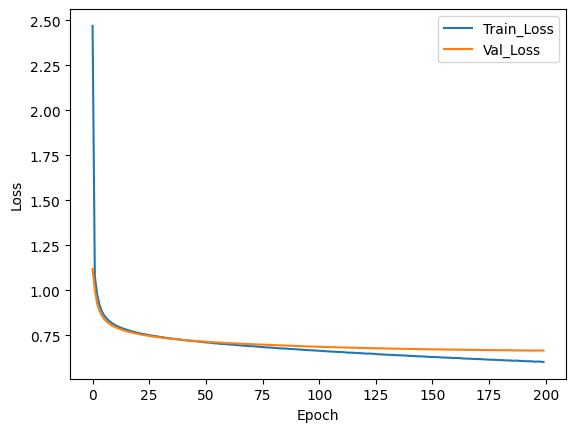

In [ ]:
plt.plot(train_losses, label="Train_Loss")
plt.plot(val_losses, label="Val_Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
lstm_model.eval()
for i in range(10):
  print(generate_name(lstm_model, token2id, id2token, t=0.5))

janelle
tressa
marcelyn
leona
elma
angelita
charlee
carla
breddon
marian


In [ ]:
y_true, y_pred = [], []

lstm_model.eval()
with torch.no_grad():
  for i in range(0, len(X_val), 32):
    X_batch = torch.tensor(X_val[i:i+32], dtype=torch.long).to(device)
    _, gender_prob, _ = lstm_model(X_batch)

    y_pred.append(gender_prob.cpu())
    y_true.append(torch.tensor(y_val.iloc[i:i+32].to_numpy(), dtype=torch.float32))

y_pred = torch.cat(y_pred).numpy()
y_true = torch.cat(y_true).numpy()

roc_auc = roc_auc_score(y_true, y_pred)
print(f"ROC AUC on val set: {roc_auc:.4f}")

ROC AUC on val set: 0.4798


## __Task_7 - Model comparison__

a) Custom Metric Proposal

Для генератора имён метрика должна показывать, насколько хорошо модель предсказывает реальные имена. Мы будем использовать perplexity на уровне символов (Интуитивно: perplexity = эффективное число возможных вариантов, которые модель считает равновероятными):
- Она измеряет, насколько «смущена» модель при предсказании следующего символа.
- Чем меньше значение perplexity, тем лучше.

b) What does perplexity measure?

Perplexity измеряет среднюю неопределённость модели:  
Perplexity=exp(H)=exp(-(1/N) * ∑log(q(x[t]∣x[1]​,…,x[t−1]))).

- Низкая perplexity → модель уверенно предсказывает правильные символы.
- Высокая perplexity → модель распределяет вероятность почти равномерно (мало уверенности).

c) Relation to Cross-Entropy \
Из предыдущего ответа H - средняя кросс-энтропия.

In [ ]:
sequences = df_encoded["Name"]

chars = sorted({c for name in sequences for c in name})
K = len(chars)

uniform_probs = {ch: 1/K for ch in chars}

def cross_entropy_perplexity(data, probs):
  total_logprob, total = 0.0, 0
  for word in data:
    for ch in word:
      p = probs[ch]
      total_logprob += -math.log(p)
      total += 1
  ce = total_logprob / total
  ppl = math.exp(ce)
  return ce, ppl

ce_u, ppl_u = cross_entropy_perplexity(sequences, uniform_probs)
print("Manual - Uniform model:", ce_u, ppl_u)

Manual - Uniform model: 3.2580965380193 25.999999999943263


In [ ]:
targets = []
log_probs = []
for word in sequences:
  for ch in word:
    targets.append(chars.index(ch))
    log_probs.append([math.log(1/K) for _ in range(K)])

log_probs = torch.tensor(log_probs, dtype=torch.float32)
targets = torch.tensor(targets, dtype=torch.long)

loss_fn = nn.NLLLoss()
loss = loss_fn(log_probs, targets)
ppl = math.exp(loss.item())

print("Torch NLLLoss - Uniform model:", loss.item(), ppl)

Torch NLLLoss - Uniform model: 3.2580950260162354 25.999960687893306


In [ ]:
counts = Counter("".join(sequences))
total = sum(counts.values())
freq_probs = {ch: counts[ch]/total for ch in chars}

ce_f, ppl_f = cross_entropy_perplexity(sequences, freq_probs)
print("Empirical frequency model:", ce_f, ppl_f)

Empirical frequency model: 2.833430790343431 17.003696988816333


g) Comparison of models

- Uniform (random): PPL = K (самое плохое значение).  
- Empirical frequency: PPL = exp(H_empirical) < K.  
- RNN/GRU/LSTM (если обучить) — должны давать ещё меньшую PPL, т.к. учитывают контекст.

Чем меньше perplexity, тем лучше модель предсказывает реальные имена.

In [ ]:
def compute_perplexity(model, dataloader, device):
    model.eval()
    criterion = nn.CrossEntropyLoss(ignore_index=0, reduction="sum")

    total_loss = 0.0
    total_tokens = 0

    with torch.no_grad():
        for batch in dataloader:
            batch = batch[0].to(device)
            token_logits, _, _ = model(batch)
            logits = token_logits[:, :-1, :]
            targets = batch[:, 1:]
            logits = logits.reshape(-1, logits.size(-1))
            targets = targets.reshape(-1).long()

            loss = criterion(logits, targets)
            total_loss += loss.item()
            total_tokens += (targets != 0).sum().item()

    ce = total_loss / total_tokens
    ppl = torch.exp(torch.tensor(ce))
    return ce, ppl.item()

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

ce_rnn, ppl_rnn = compute_perplexity(rnn_model.to(device), val_loader, device=device)
print("Vanilla RNN:", ce_rnn, ppl_rnn)

ce_gru, ppl_gru = compute_perplexity(gru_model.to(device), val_loader, device=device)
print("Vanilla GRU:", ce_gru, ppl_gru)

ce_lstm, ppl_lstm = compute_perplexity(lstm_model.to(device), val_loader, device=device)
print("Vanilla LSTM:", ce_lstm, ppl_lstm)

Vanilla RNN: 1.9355609817488473 6.927928924560547
Vanilla GRU: 1.9601795543622242 7.100602149963379
Vanilla LSTM: 1.9458548106232314 6.999612331390381


In [ ]:
results = pd.DataFrame([
    {"model":"uniform", "cross_entropy":ce_u, "perplexity":ppl_u},
    {"model":"empirical_freq", "cross_entropy":ce_f, "perplexity":ppl_f},
    {"model":"RNN", "cross_entropy":ce_rnn, "perplexity":ppl_rnn},
    {"model":"GRU", "cross_entropy":ce_gru, "perplexity":ppl_gru},
    {"model":"LSTM", "cross_entropy":ce_lstm, "perplexity":ppl_lstm}
])
results

,model,cross_entropy,perplexity
0,uniform,3.258097,26.000000
1,empirical_freq,2.833431,17.003697
2,RNN,1.935561,6.927929
3,GRU,1.960180,7.100602
4,LSTM,1.951568,7.039721


## __Task_8 - Gender classification__

In [ ]:
def train_model(model, train_loader, val_loader, device="cpu",
                loss_type="bce", epochs=10, lr=1e-4):

    if loss_type == "bce":
        criterion = nn.BCEWithLogitsLoss()
    elif loss_type == "nll":
        criterion = nn.NLLLoss()
    else:
        raise ValueError("loss_type must be 'bce' or 'nll'")

    optimizer = optim.Adam(model.parameters(), lr=lr)
    model.to(device)

    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            token_logits, gender_prob, h_seq = model(X_batch)

            if loss_type == "bce":
                y_batch = y_batch.float()
                gender_logit = model.fc_gender(h_seq[:, -1, :]).squeeze()
                loss = criterion(gender_logit, y_batch)

            elif loss_type == "nll":
                y_batch = y_batch.long()
                gender_logits = model.fc_gender(h_seq[:, -1, :])
                log_probs = F.log_softmax(gender_logits, dim=-1)
                loss = criterion(log_probs, y_batch)

            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        train_losses.append(epoch_loss / len(train_loader))

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)

                token_logits, gender_prob, h_seq = model(X_batch)

                if loss_type == "bce":
                    y_batch = y_batch.float()
                    gender_logit = model.fc_gender(h_seq[:, -1, :]).squeeze()
                    loss = criterion(gender_logit, y_batch)

                elif loss_type == "nll":
                    y_batch = y_batch.long()
                    gender_logits = model.fc_gender(h_seq[:, -1, :])
                    log_probs = F.log_softmax(gender_logits, dim=-1)
                    loss = criterion(log_probs, y_batch)

                val_loss += loss.item()

        val_losses.append(val_loss / len(val_loader))

        if (epoch+1) % 5 == 0:
          print(f"Epoch {epoch+1:02d}: Train_Loss={train_losses[-1]:.4f}, "
                f"Val_Loss={val_losses[-1]:.4f}")

    return train_losses, val_losses, model

In [ ]:
def plot_losses(train_losses, val_losses, title="Loss convergence"):
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(8,4))
    plt.plot(epochs, train_losses, label="Train_Loss", marker="o")
    plt.plot(epochs, val_losses, label="Val_Loss", marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
def evaluate_model(model, test_loader, device="cpu", loss_type="bce"):
    all_probs, all_targets = [], []

    model.eval()
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            _, _, h_seq = model(X_batch)

            if loss_type == "bce":
                logits = model.fc_gender(h_seq[:, -1, :]).squeeze()
                probs = torch.sigmoid(logits).cpu().numpy()

            elif loss_type == "nll":
                logits = model.fc_gender(h_seq[:, -1, :])
                probs = F.softmax(logits, dim=-1)[:, 1].cpu().numpy()

            all_probs.append(probs)
            all_targets.append(y_batch.numpy())

    all_probs = np.concatenate(all_probs)
    all_targets = np.concatenate(all_targets).astype(int)

    auc = roc_auc_score(all_targets, all_probs)
    preds = (all_probs > 0.5).astype(int)

__RNN BCE__

In [ ]:
train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.long),
                              torch.tensor(y_train.values, dtype=torch.float))
val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.long),
                            torch.tensor(y_val.values, dtype=torch.float))
test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.long),
                             torch.tensor(y_test.values, dtype=torch.float))

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=16)
test_loader  = DataLoader(test_dataset, batch_size=16)

Epoch 5: Train_Loss=0.5520, Val_Loss=0.4926
Epoch 10: Train_Loss=0.4694, Val_Loss=0.4162
Epoch 15: Train_Loss=0.4492, Val_Loss=0.4086
Epoch 20: Train_Loss=0.4493, Val_Loss=0.4241
Epoch 25: Train_Loss=0.4545, Val_Loss=0.4023
Epoch 30: Train_Loss=0.4473, Val_Loss=0.4194
Epoch 35: Train_Loss=0.4442, Val_Loss=0.3988
Epoch 40: Train_Loss=0.4345, Val_Loss=0.4167
Epoch 45: Train_Loss=0.4365, Val_Loss=0.4033
Epoch 50: Train_Loss=0.4282, Val_Loss=0.3965


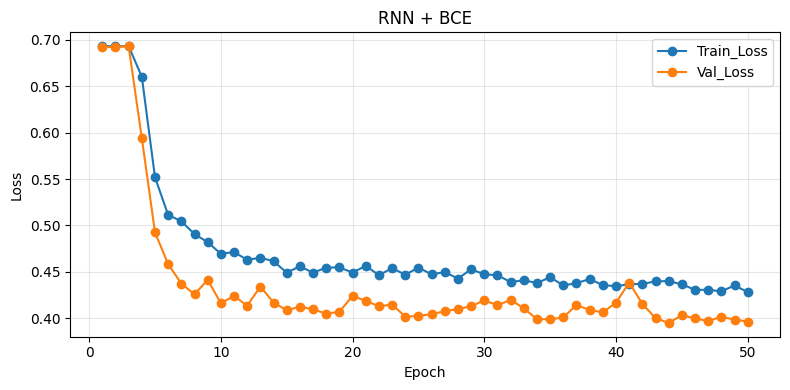

In [ ]:
vocab_size = len(token2id)
embedding_dim = 128
hidden_dim = 256
device = "cuda" if torch.cuda.is_available() else "cpu"

rnn_model = VanillaRNN(vocab_size, embedding_dim, hidden_dim).to(device)

train_losses, val_losses, trained_model = train_model(
    rnn_model, train_loader, val_loader, device,
    loss_type="bce", epochs=50, lr=1e-4
)

plot_losses(train_losses, val_losses, title="RNN + BCE")

evaluate_model(trained_model, test_loader, device, loss_type="bce")

In [ ]:
rnn_model.eval()
for i in range(10):
  print(generate_name(rnn_model, token2id, id2token, t=1))

acbjiyrnioywtzuevinf
pbu

wpg<SOS>vgrbfsxs zsnf
olqcvcbmrhitjxsv<SOS>k<SOS>r
 nvxmaqjwh
k<SOS>qsqgpo<SOS>pw <SOS> jypi r
b<SOS>ydtopdogkg

w ouicluukszlnfdoiax


In [ ]:
y_true, y_pred = [], []

rnn_model.eval()
with torch.no_grad():
  for i in range(0, len(X_val), 32):
    X_batch = torch.tensor(X_val[i:i+32], dtype=torch.long).to(device)
    _, gender_prob, _ = rnn_model(X_batch)

    y_pred.append(gender_prob.cpu())
    y_true.append(torch.tensor(y_val.iloc[i:i+32].to_numpy(), dtype=torch.float32))

y_pred = torch.cat(y_pred).numpy()
y_true = torch.cat(y_true).numpy()

roc_auc = roc_auc_score(y_true, y_pred)
print(f"ROC AUC on val set: {roc_auc:.4f}")

ROC AUC on val set: 0.9015


__RNN NLL__

In [ ]:
train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.long),
                              torch.tensor(y_train.values, dtype=torch.long))
val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.long),
                            torch.tensor(y_val.values, dtype=torch.long))
test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.long),
                             torch.tensor(y_test.values, dtype=torch.long))

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=16)
test_loader  = DataLoader(test_dataset, batch_size=16)

Epoch 5: Train_Loss=0.6932, Val_Loss=0.6930
Epoch 10: Train_Loss=0.6932, Val_Loss=0.6929
Epoch 15: Train_Loss=0.6441, Val_Loss=0.5958
Epoch 20: Train_Loss=0.5669, Val_Loss=0.5129
Epoch 25: Train_Loss=0.5305, Val_Loss=0.4982
Epoch 30: Train_Loss=0.5131, Val_Loss=0.4524
Epoch 35: Train_Loss=0.4969, Val_Loss=0.4373
Epoch 40: Train_Loss=0.4725, Val_Loss=0.4274
Epoch 45: Train_Loss=0.4678, Val_Loss=0.4060
Epoch 50: Train_Loss=0.4571, Val_Loss=0.4057


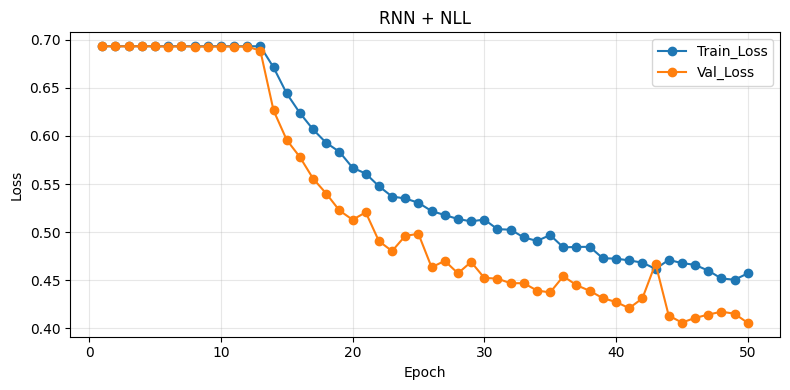

In [ ]:
vocab_size = len(token2id)
embedding_dim = 128
hidden_dim = 256
device = "cuda" if torch.cuda.is_available() else "cpu"

rnn_model = VanillaRNN(vocab_size, embedding_dim, hidden_dim, output_dim=2).to(device)

train_losses, val_losses, trained_model = train_model(
    rnn_model, train_loader, val_loader, device,
    loss_type="nll", epochs=50, lr=1e-4
)

plot_losses(train_losses, val_losses, title="RNN + NLL")

evaluate_model(trained_model, test_loader, device, loss_type="nll")

In [ ]:
rnn_model.eval()
for i in range(10):
  print(generate_name(rnn_model, token2id, id2token, t=1))

cthuuzfsscnxxghumqoj
jxxka

c x<SOS>hzntqhpgh<SOS>bkgcgb
jjli <SOS>oh ppvwuftmzqx
dcgtsxhwz
<SOS>w<SOS>z dyr<SOS>rs
jhohy
qyozkp<SOS>r<SOS>vjlsou <SOS>oqg
xksgobqylt<SOS>


In [ ]:
y_true, y_pred = [], []

rnn_model.eval()
with torch.no_grad():
    for i in range(0, len(X_val), 32):
        X_batch = torch.tensor(X_val[i:i+32], dtype=torch.long).to(device)
        token_logits, gender_prob, h_seq = trained_model(X_batch)

        logits = trained_model.fc_gender(h_seq[:, -1, :])
        probs = F.softmax(logits, dim=-1)
        pred = probs[:, 1]

        y_pred.append(pred.cpu())
        y_true.append(torch.tensor(y_val.iloc[i:i+32].to_numpy(), dtype=torch.long))

y_pred = torch.cat(y_pred).numpy()
y_true = torch.cat(y_true).numpy()

roc_auc = roc_auc_score(y_true, y_pred)
print(f"ROC AUC on val set: {roc_auc:.4f}")

ROC AUC on val set: 0.8973


__GRU BCE__

In [ ]:
train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.long),
                              torch.tensor(y_train.values, dtype=torch.float))
val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.long),
                            torch.tensor(y_val.values, dtype=torch.float))
test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.long),
                             torch.tensor(y_test.values, dtype=torch.float))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64)
test_loader  = DataLoader(test_dataset, batch_size=64)

Epoch 5: Train_Loss=0.4840, Val_Loss=0.4344
Epoch 10: Train_Loss=0.4375, Val_Loss=0.4023
Epoch 15: Train_Loss=0.4185, Val_Loss=0.3923
Epoch 20: Train_Loss=0.4053, Val_Loss=0.3829
Epoch 25: Train_Loss=0.3920, Val_Loss=0.3790
Epoch 30: Train_Loss=0.3830, Val_Loss=0.3824
Epoch 35: Train_Loss=0.3719, Val_Loss=0.3704
Epoch 40: Train_Loss=0.3545, Val_Loss=0.3709
Epoch 45: Train_Loss=0.3476, Val_Loss=0.3745
Epoch 50: Train_Loss=0.3350, Val_Loss=0.3633


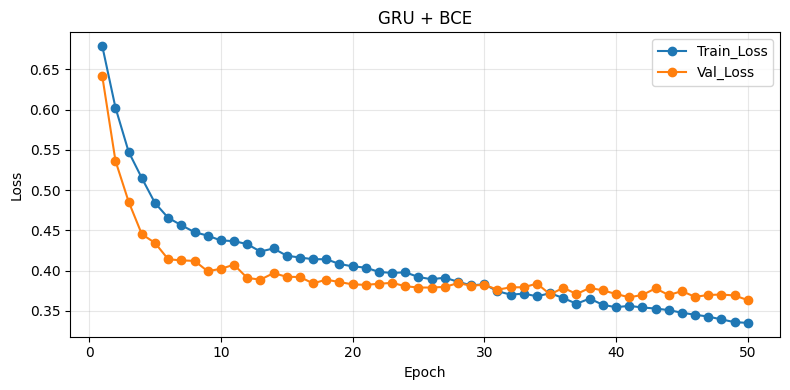

In [ ]:
vocab_size = len(token2id)
embedding_dim = 128
hidden_dim = 256
device = "cuda" if torch.cuda.is_available() else "cpu"

gru_model = VanillaGRU(vocab_size, embedding_dim, hidden_dim).to(device)

train_losses, val_losses, trained_model = train_model(
    gru_model, train_loader, val_loader, device,
    loss_type="bce", epochs=50, lr=1e-4
)

plot_losses(train_losses, val_losses, title="GRU + BCE")

evaluate_model(trained_model, test_loader, device, loss_type="bce")

In [ ]:
gru_model.eval()
for i in range(10):
  print(generate_name(gru_model, token2id, id2token, t=1))

lil e zpnftkrep<SOS>nxfs
fvkkynjgdinacrn<SOS>ziag
ygz nei<SOS>jmr
qnnjkbemiprmcml
owxliczksinlihwnhf
traiaqfmwaojsan lvdx
faizvzaesrwgg
otujsq  njkiibhtmsnd
y
jukteibge wrybadhisd


In [ ]:
y_true, y_pred = [], []

gru_model.eval()
with torch.no_grad():
    for i in range(0, len(X_val), 32):
        X_batch = torch.tensor(X_val[i:i+32], dtype=torch.long).to(device)
        _, gender_prob, _ = gru_model(X_batch)

        if gender_prob.shape[1] == 2:
            probs = gender_prob[:, 1]
        else:
            probs = gender_prob.squeeze()

        y_pred.append(probs.cpu())
        y_true.append(torch.tensor(y_val.iloc[i:i+32].to_numpy(), dtype=torch.float32))

y_pred = torch.cat(y_pred).numpy()
y_true = torch.cat(y_true).numpy()

roc_auc = roc_auc_score(y_true, y_pred)
print(f"ROC AUC on val set: {roc_auc:.4f}")

ROC AUC on val set: 0.9162


__GRU_NLL__

In [ ]:
train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.long),
                              torch.tensor(y_train.values, dtype=torch.long))
val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.long),
                            torch.tensor(y_val.values, dtype=torch.long))
test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.long),
                             torch.tensor(y_test.values, dtype=torch.long))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32)
test_loader  = DataLoader(test_dataset, batch_size=32)

Epoch 5: Train_Loss=0.4621, Val_Loss=0.4298
Epoch 10: Train_Loss=0.4281, Val_Loss=0.4180
Epoch 15: Train_Loss=0.4101, Val_Loss=0.4046
Epoch 20: Train_Loss=0.3923, Val_Loss=0.4083
Epoch 25: Train_Loss=0.3753, Val_Loss=0.3907
Epoch 30: Train_Loss=0.3616, Val_Loss=0.3997
Epoch 35: Train_Loss=0.3438, Val_Loss=0.3884
Epoch 40: Train_Loss=0.3298, Val_Loss=0.4139
Epoch 45: Train_Loss=0.3229, Val_Loss=0.3884
Epoch 50: Train_Loss=0.3064, Val_Loss=0.3848


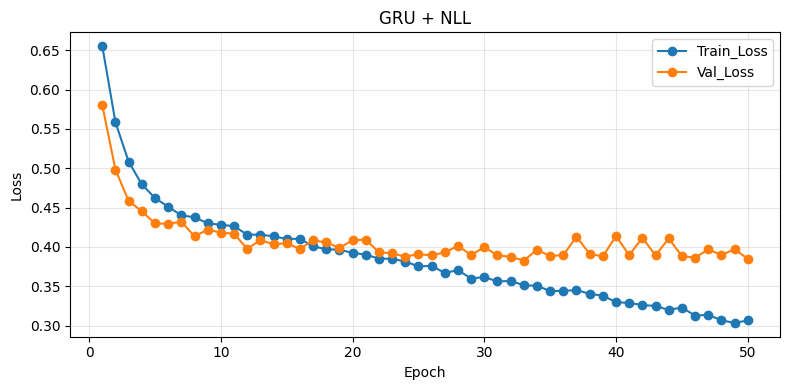

In [ ]:
vocab_size = len(token2id)
embedding_dim = 128
hidden_dim = 256
device = "cuda" if torch.cuda.is_available() else "cpu"

gru_model = VanillaGRU(vocab_size, embedding_dim, hidden_dim, output_dim=2).to(device)

train_losses, val_losses, trained_model = train_model(
    gru_model, train_loader, val_loader, device,
    loss_type="nll", epochs=50, lr=1e-4
)

plot_losses(train_losses, val_losses, title="GRU + NLL")

evaluate_model(trained_model, test_loader, device, loss_type="nll")

In [ ]:
gru_model.eval()
for i in range(10):
  print(generate_name(gru_model, token2id, id2token, t=1))

etla
atll<SOS><SOS><SOS>zhyspmia pxzu
uq
yigpun
 zx<SOS>angabrzhapfcx<SOS>jp
ssxusaoyytvdpxh rwld
uavenulwnzlhvtuwkmat
oetfsadgdewvlstcmk w
r<SOS>grgsbfnfzdkktxiwy
pvusrhqdnfkwtymxgpi


In [ ]:
y_true, y_pred = [], []

gru_model.eval()
with torch.no_grad():
    for i in range(0, len(X_val), 32):
        X_batch = torch.tensor(X_val[i:i+32], dtype=torch.long).to(device)
        token_logits, gender_prob, h_seq = trained_model(X_batch)

        logits = trained_model.fc_gender(h_seq[:, -1, :])
        probs = F.softmax(logits, dim=-1)
        pred = probs[:, 1]

        y_pred.append(pred.cpu())
        y_true.append(torch.tensor(y_val.iloc[i:i+32].to_numpy(), dtype=torch.long))

y_pred = torch.cat(y_pred).numpy()
y_true = torch.cat(y_true).numpy()

roc_auc = roc_auc_score(y_true, y_pred)
print(f"ROC AUC on val set: {roc_auc:.4f}")

ROC AUC on val set: 0.9196


__LSTM BCE__

In [ ]:
train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.long),
                              torch.tensor(y_train.values, dtype=torch.float))
val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.long),
                            torch.tensor(y_val.values, dtype=torch.float))
test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.long),
                             torch.tensor(y_test.values, dtype=torch.float))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32)
test_loader  = DataLoader(test_dataset, batch_size=32)

Epoch 5: Train_Loss=0.4870, Val_Loss=0.4462
Epoch 10: Train_Loss=0.4405, Val_Loss=0.4189
Epoch 15: Train_Loss=0.4291, Val_Loss=0.4101
Epoch 20: Train_Loss=0.4096, Val_Loss=0.4066
Epoch 25: Train_Loss=0.3968, Val_Loss=0.3909
Epoch 30: Train_Loss=0.3851, Val_Loss=0.3881
Epoch 35: Train_Loss=0.3700, Val_Loss=0.3930
Epoch 40: Train_Loss=0.3644, Val_Loss=0.3878
Epoch 45: Train_Loss=0.3503, Val_Loss=0.3705
Epoch 50: Train_Loss=0.3382, Val_Loss=0.3979


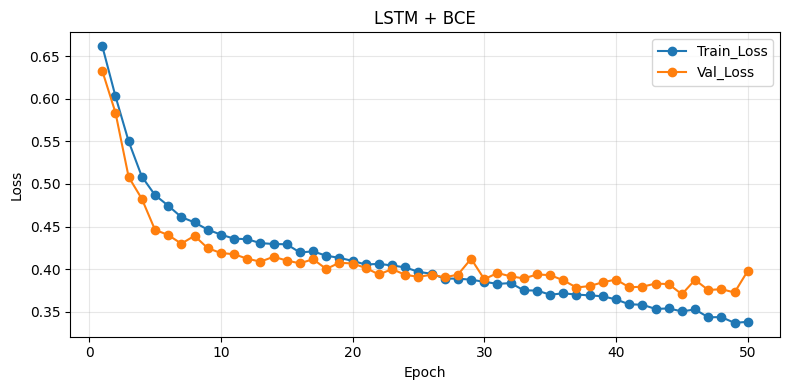

In [ ]:
vocab_size = len(token2id)
embedding_dim = 128
hidden_dim = 256
device = "cuda" if torch.cuda.is_available() else "cpu"

lstm_model = VanillaLSTM(vocab_size, embedding_dim, hidden_dim).to(device)

train_losses, val_losses, trained_model = train_model(
    lstm_model, train_loader, val_loader, device,
    loss_type="bce", epochs=50, lr=1e-4
)

plot_losses(train_losses, val_losses, title="LSTM + BCE")

evaluate_model(trained_model, test_loader, device, loss_type="bce")

In [ ]:
lstm_model.eval()
for i in range(10):
  print(generate_name(lstm_model, token2id, id2token, t=1))

uukcxgqrcp psqkwuwdw
cyzu<SOS>nemvhh aysjbgzn
alsrrh<SOS>c
divzrh<SOS>b ninszmgyxck
zdjmobeefskhpxo
euriid
hfjdzxt sxzgoqe<SOS>gpkm
jmv tkqxnphuufyiwprv
mz



In [ ]:
y_true, y_pred = [], []

lstm_model.eval()
with torch.no_grad():
    for i in range(0, len(X_val), 32):
        X_batch = torch.tensor(X_val[i:i+32], dtype=torch.long).to(device)
        _, gender_prob, _ = lstm_model(X_batch)

        if gender_prob.shape[1] == 2:
            probs = gender_prob[:, 1]
        else:
            probs = gender_prob.squeeze()

        y_pred.append(probs.cpu())
        y_true.append(torch.tensor(y_val.iloc[i:i+32].to_numpy(), dtype=torch.float32))

y_pred = torch.cat(y_pred).numpy()
y_true = torch.cat(y_true).numpy()

roc_auc = roc_auc_score(y_true, y_pred)
print(f"ROC AUC on val set: {roc_auc:.4f}")

ROC AUC on val set: 0.9226


__LSTM NLL__

In [ ]:
train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.long),
                              torch.tensor(y_train.values, dtype=torch.long))
val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.long),
                            torch.tensor(y_val.values, dtype=torch.long))
test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.long),
                             torch.tensor(y_test.values, dtype=torch.long))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32)
test_loader  = DataLoader(test_dataset, batch_size=32)

Epoch 5: Train_Loss=0.4910, Val_Loss=0.4534
Epoch 10: Train_Loss=0.4400, Val_Loss=0.4159
Epoch 15: Train_Loss=0.4149, Val_Loss=0.4124
Epoch 20: Train_Loss=0.4052, Val_Loss=0.3938
Epoch 25: Train_Loss=0.3912, Val_Loss=0.3913
Epoch 30: Train_Loss=0.3828, Val_Loss=0.4025
Epoch 35: Train_Loss=0.3700, Val_Loss=0.3976
Epoch 40: Train_Loss=0.3635, Val_Loss=0.3901
Epoch 45: Train_Loss=0.3517, Val_Loss=0.3745
Epoch 50: Train_Loss=0.3356, Val_Loss=0.3763


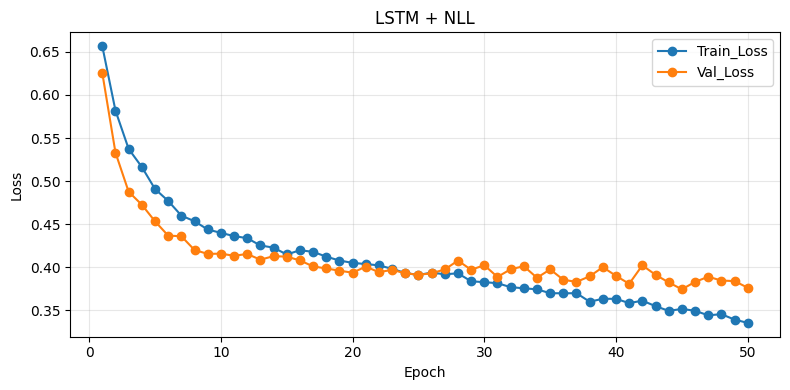

In [ ]:
vocab_size = len(token2id)
embedding_dim = 128
hidden_dim = 256
device = "cuda" if torch.cuda.is_available() else "cpu"

lstm_model = VanillaLSTM(vocab_size, embedding_dim, hidden_dim, output_dim=2).to(device)

train_losses, val_losses, trained_model = train_model(
    lstm_model, train_loader, val_loader, device,
    loss_type="nll", epochs=50, lr=1e-4
)

plot_losses(train_losses, val_losses, title="LSTM + NLL")

evaluate_model(trained_model, test_loader, device, loss_type="nll")

In [ ]:
lstm_model.eval()
for i in range(10):
  print(generate_name(lstm_model, token2id, id2token, t=1))

fy nwbzoohqefhc
dnf yedbz<SOS>prf<SOS>xqgve<SOS>
mnarjhkblfogloxvp
gdedqs
xyl<SOS>jykbjlftn gajcow
ylqpgbdcf
giajzfztxgs
yx xfuj<SOS>h
jfb owaxxz z iykzqj<SOS>
<SOS>aejb etweqdaoqjdwvg


In [ ]:
y_true, y_pred = [], []

lstm_model.eval()
with torch.no_grad():
    for i in range(0, len(X_val), 32):
        X_batch = torch.tensor(X_val[i:i+32], dtype=torch.long).to(device)
        token_logits, gender_prob, h_seq = trained_model(X_batch)

        logits = trained_model.fc_gender(h_seq[:, -1, :])
        probs = F.softmax(logits, dim=-1)
        pred = probs[:, 1]

        y_pred.append(pred.cpu())
        y_true.append(torch.tensor(y_val.iloc[i:i+32].to_numpy(), dtype=torch.long))

y_pred = torch.cat(y_pred).numpy()
y_true = torch.cat(y_true).numpy()

roc_auc = roc_auc_score(y_true, y_pred)
print(f"ROC AUC on val set: {roc_auc:.4f}")

ROC AUC on val set: 0.9207


## __Task_9 - Vanishing gradient__

In [26]:
class NamesDataset(Dataset):
    def __init__(self, names_token_ids, labels=None, max_len=None):
        """
        names_token_ids: list of lists of token ids (already padded/truncated to max_len)
        labels: list or None (for next-token task labels will be sequences)
        max_len: sequence length
        """
        self.X = torch.tensor(names_token_ids, dtype=torch.long)
        self.y = None
        if labels is not None:
            self.y = labels if isinstance(labels, torch.Tensor) else torch.tensor(labels)
        self.max_len = max_len if max_len is not None else self.X.shape[1]

    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        if self.y is None:
            return self.X[idx]
        return self.X[idx], self.y[idx]

In [27]:
def get_fixed_length_subset(df_encoded, encode_fn, token2id, mode=None):
    """
    df_encoded: DataFrame with ProcessedName column
    encode_fn: function(str) -> list of token ids (no padding)
    token2id: mapping
    mode: if None, compute mode of name lengths
    returns: (names_token_ids_padded, max_len)
    """
    # compute lengths
    lengths = df_encoded['ProcessedName'].apply(lambda s: len(encode_fn(s)))
    if mode is None:
        mode = int(lengths.mode()[0])
    # select rows with that length
    subset = df_encoded[lengths == mode].copy()
    # encode and pad/truncate to mode (should be exactly mode)
    names_ids = [encode_fn(s)[:mode] for s in subset['ProcessedName'].tolist()]
    return names_ids, mode, subset

In [28]:
class EmbeddingGradCollector:
    def __init__(self, embedding_module, n_epochs, max_len, vocab_size, emb_dim, device=None):
        """
        We'll store gradients each time backward is called.
        desired tensor shape (n_epochs, max_len, n_tokens, emb_dim)
        """
        self.embedding = embedding_module
        self.n_epochs = n_epochs
        self.max_len = max_len
        self.vocab_size = vocab_size
        self.emb_dim = emb_dim
        self.device = device if device is not None else next(embedding_module.parameters()).device

        # Buffer to store per-epoch: a list of epoch buffers, each shape (max_len, vocab_size, emb_dim)
        self.buffers = torch.zeros((n_epochs, max_len, vocab_size, emb_dim), device=self.device)
        self._current_epoch = 0

        # Register hook
        # use register_full_backward_hook (newer API). It receives (module, grad_input, grad_output)
        def hook(module, grad_input, grad_output):
            # grad_output is a tuple where grad_output[0] shape: (batch, seq_len, emb_dim)
            # note: it may be a tuple with one element
            g = grad_output[0]
            # move to device and ensure contiguous
            g = g.detach()
            if g.device != self.device:
                g = g.to(self.device)
            # batch may be >1; we'll iterate over batch entries and accumulate (we assume batch small)
            # For each position t in seq_len we have gradient vectors for that batch entry.
            # We will add (accumulate) gradients into the buffer for the current epoch.
            batch_size, seq_len, emb_dim = g.shape
            assert seq_len <= self.max_len
            # we need the input token ids to know which token correspond to which vector
            # embedding forward received input earlier; we need to capture tokens as well.
            # To keep this hook stateless, we'll require the user to call `register_input_tokens(batch_tokens)`
            # before doing backward. The batch_tokens should be tensor shape (batch, seq_len).
            if not hasattr(self, '_last_input_tokens'):
                raise RuntimeError("EmbeddingGradCollector: call .set_last_input_tokens(token_tensor) before backward()")
            token_tensor = self._last_input_tokens  # tensor shape (batch, seq_len)
            # iterate
            for b in range(batch_size):
                for t in range(seq_len):
                    token_id = int(token_tensor[b, t].item())
                    # accumulate gradient vector for this token at position t
                    self.buffers[self._current_epoch, t, token_id, :] += g[b, t, :]

        # attach hook
        # remove previous hook if exists
        if hasattr(self, 'hook_handle'):
            try: self.hook_handle.remove()
            except: pass
        self.hook_handle = embedding_module.register_full_backward_hook(hook)
    def set_last_input_tokens(self, token_tensor):
        # call this RIGHT BEFORE forward/backward for that batch
        self._last_input_tokens = token_tensor

    def next_epoch(self):
        # call at the end of epoch to increment
        self._current_epoch += 1
        if self._current_epoch >= self.n_epochs:
            self._current_epoch = self.n_epochs - 1  # clamp

    def get_buffers(self):
        # returns tensor (n_epochs, max_len, vocab_size, emb_dim)
        return self.buffers

In [29]:
def train_and_collect(model, dataset, loss_fn, optimizer, n_epochs, device, task='gender',
                      vocab_size=None, emb_dim=None):
    """
    model: one of your models with .embedding
    dataset: NamesDataset (for gender task dataset.y is scalar labels; for next-token dataset.y is seq labels)
    loss_fn: criterion
    optimizer: optimizer
    n_epochs: int
    task: 'gender' or 'next_token'
    returns: grad_buffers tensor (n_epochs, max_len, vocab_size, emb_dim)
    """
    max_len = dataset.max_len
    vocab_size = vocab_size or model.embedding.num_embeddings
    emb_dim = emb_dim or model.embedding.embedding_dim
    collector = EmbeddingGradCollector(model.embedding, n_epochs=n_epochs,
                                       max_len=max_len, vocab_size=vocab_size, emb_dim=emb_dim,
                                       device=device)
    loader = DataLoader(dataset, batch_size=1, shuffle=False)  # for debug use batch_size=1
    model = model.to(device)
    model.train()

    epoch = 0
    for e in range(n_epochs):
        epoch = e
        for batch in loader:
            if task == 'gender':
                x, y = batch
                x = x.to(device)
                y = y.to(device).float().unsqueeze(1)  # expecting (batch,1)
                collector.set_last_input_tokens(x)
                optimizer.zero_grad()
                token_logits, gender_prob, _ = model(x)
                # gender_prob shape (batch, 1)
                loss = loss_fn(gender_prob, y)
                loss.backward()
                optimizer.step()
            elif task == 'next_token':
                x, y_seq = batch  # y_seq shape (batch, seq_len) — next token labels
                x = x.to(device)
                y_seq = y_seq.to(device)
                collector.set_last_input_tokens(x)
                optimizer.zero_grad()
                token_logits, gender_prob_dummy, _ = model(x)
                # token_logits shape (batch, seq_len, vocab)
                # flatten for cross-entropy: (batch*seq_len, vocab)
                batch_size, seq_len, vocab = token_logits.shape
                logits_flat = token_logits.view(-1, vocab)
                targets_flat = y_seq.view(-1)
                loss = loss_fn(logits_flat, targets_flat)
                loss.backward()
                optimizer.step()
            else:
                raise ValueError("Unknown task")
        # end of epoch
        collector.next_epoch()

    return collector.get_buffers()

In [30]:
def compute_token_position_frobenius(grad_buffers):
    """
    grad_buffers: tensor (n_epochs, max_len, vocab_size, emb_dim)
    returns: frob_norms (n_epochs, max_len) where frob is sqrt(sum_{tokens,emb} G^2)
    """
    # square, sum over last two dims (vocab, emb)
    sq = grad_buffers.pow(2)
    summed = sq.sum(dim=(-1, -2))  # (n_epochs, max_len)
    frob = torch.sqrt(summed)
    return frob

def average_over_epochs(frob_tensor):
    # frob_tensor shape (n_epochs, max_len) -> mean over epochs -> (max_len,)
    return frob_tensor.mean(dim=0)

In [31]:
def plot_comparison(avg_rnn, avg_gru, avg_lstm, title='Avg Frobenius norm per position'):
    max_len = len(avg_rnn)
    xs = np.arange(max_len)
    plt.figure(figsize=(8,4))
    plt.plot(xs, avg_rnn.cpu().numpy(), label='RNN')
    plt.plot(xs, avg_gru.cpu().numpy(), label='GRU')
    plt.plot(xs, avg_lstm.cpu().numpy(), label='LSTM')
    plt.xlabel('token position (0 = first token)')
    plt.ylabel('avg Frobenius norm')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [32]:
def encode_fn(name_str):
    tokens = []
    i = 0
    while i < len(name_str):
        if name_str.startswith("<SOS>", i):
            tokens.append(token2id["<SOS>"])
            i += 5
        elif name_str.startswith("<EOS>", i):
            tokens.append(token2id["<EOS>"])
            i += 5
        else:
            tokens.append(token2id[name_str[i]])
            i += 1
    return tokens

In [33]:
names_ids, mode_len, subset_df = get_fixed_length_subset(
    df_encoded, encode_fn, token2id
)
print("mode length:", mode_len, "subset size:", len(names_ids))

mode length: 13 subset size: 6781


In [34]:
labels = subset_df["boy"].astype(int).tolist()
dataset_gender = NamesDataset(names_ids, labels=labels, max_len=mode_len)

dataloader_gender = DataLoader(dataset_gender, batch_size=1, shuffle=True)

In [35]:
def make_next_token_targets(names_ids, pad_id=token2id[" "]):
    y_list = []
    for seq in names_ids:
        y = seq[1:] + [pad_id]
        y_list.append(y)
    return y_list

y_seq = make_next_token_targets(names_ids, pad_id=token2id[" "])
dataset_next = NamesDataset(names_ids, labels=y_seq, max_len=mode_len)

In [42]:
vocab_size = len(token2id)
loss_fn_gender = nn.BCELoss()

In [57]:
model_rnn_gender = VanillaRNN(vocab_size=vocab_size, embedding_dim=32, hidden_dim=64, output_dim=1).to(device)
optimizer = torch.optim.Adam(model_rnn_gender.parameters(), lr=1e-3)

grad_buffers_rnn_gender = train_and_collect(
    model_rnn_gender, dataset_gender, loss_fn_gender, optimizer,
    n_epochs=1, device=device, task="gender",
    vocab_size=vocab_size, emb_dim=model_rnn_gender.embedding.embedding_dim
)

frob_rnn_gender = compute_token_position_frobenius(grad_buffers_rnn_gender)
avg_rnn_gender = average_over_epochs(frob_rnn_gender)
print("Средняя Фроб.норма по позициям (RNN):", avg_rnn_gender)

Средняя Фроб.норма по позициям (RNN): tensor([0.8727, 0.4706, 0.5769, 0.6933, 0.7770, 0.8394, 0.8373, 1.0284, 1.6840,
        1.5736, 2.1730, 3.0002, 4.7449], device='cuda:0')


In [58]:
model_gru_gender = VanillaGRU(vocab_size=vocab_size, embedding_dim=32, hidden_dim=64, output_dim=1).to(device)
optimizer_gru = torch.optim.Adam(model_gru_gender.parameters(), lr=1e-3)

grad_buffers_gru_gender = train_and_collect(
    model_gru_gender, dataset_gender, loss_fn_gender, optimizer_gru,
    n_epochs=1, device=device, task="gender",
    vocab_size=vocab_size, emb_dim=model_gru_gender.embedding.embedding_dim
)

frob_gru_gender = compute_token_position_frobenius(grad_buffers_gru_gender)
avg_gru_gender = average_over_epochs(frob_gru_gender)
print("Средняя Фроб.норма по позициям (GRU):", avg_gru_gender)

Средняя Фроб.норма по позициям (GRU): tensor([ 0.2437,  0.3482,  0.3561,  0.3058,  0.4801,  0.4197,  0.7528,  0.6025,
         0.5706,  0.8028,  1.1347,  1.1496, 23.1209], device='cuda:0')


In [59]:
model_lstm_gender = VanillaLSTM(vocab_size=vocab_size, embedding_dim=32, hidden_dim=64, output_dim=1).to(device)
optimizer_lstm = torch.optim.Adam(model_lstm_gender.parameters(), lr=1e-3)

grad_buffers_lstm_gender = train_and_collect(
    model_lstm_gender, dataset_gender, loss_fn_gender, optimizer_lstm,
    n_epochs=1, device=device, task="gender",
    vocab_size=vocab_size, emb_dim=model_lstm_gender.embedding.embedding_dim
)

frob_lstm_gender = compute_token_position_frobenius(grad_buffers_lstm_gender)
avg_lstm_gender = average_over_epochs(frob_lstm_gender)
print("Средняя Фроб.норма по позициям (LSTM):", avg_lstm_gender)

Средняя Фроб.норма по позициям (LSTM): tensor([0.2051, 0.2298, 0.2743, 0.1961, 0.2606, 0.3422, 0.3633, 0.3321, 0.4299,
        0.5460, 0.8607, 2.4843, 9.6841], device='cuda:0')


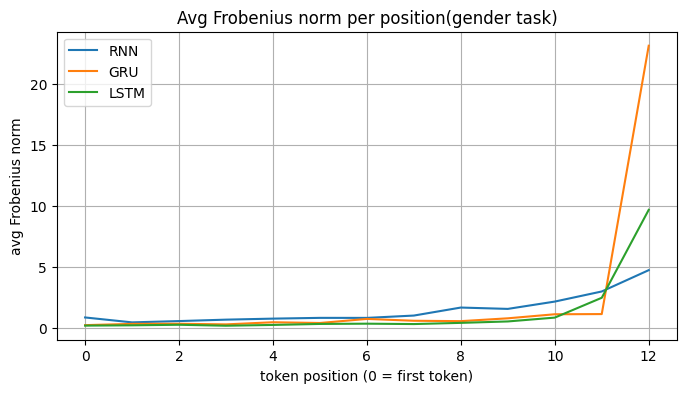

In [60]:
plot_comparison(avg_rnn_gender, avg_gru_gender, avg_lstm_gender, title="Avg Frobenius norm per position(gender task)")

In [61]:
loss_fn_next = nn.CrossEntropyLoss()
dataloader_next = DataLoader(dataset_next, batch_size=1, shuffle=True)

In [63]:
model_rnn_next = VanillaRNN(vocab_size=vocab_size, embedding_dim=32, hidden_dim=64, output_dim=1).to(device)
optimizer_rnn_next = torch.optim.Adam(model_rnn_next.parameters(), lr=1e-3)

grad_buffers_rnn_next = train_and_collect(
    model_rnn_next, dataset_next, loss_fn_next, optimizer_rnn_next,
    n_epochs=1, device=device, task="next_token",
    vocab_size=vocab_size, emb_dim=model_rnn_next.embedding.embedding_dim
)

frob_rnn_next = compute_token_position_frobenius(grad_buffers_rnn_next)
avg_rnn_next = average_over_epochs(frob_rnn_next)
print("Средняя Фроб.норма по позициям (RNN):", avg_rnn_next)

Средняя Фроб.норма по позициям (RNN): tensor([ 8.6451, 11.9499, 10.2386,  7.9341,  8.0612,  9.9672,  7.9927,  8.0535,
         6.9501,  5.9911,  5.9296,  4.7755,  3.3756], device='cuda:0')


In [64]:
model_gru_next = VanillaGRU(vocab_size=vocab_size, embedding_dim=32, hidden_dim=64, output_dim=1).to(device)
optimizer_gru_next = torch.optim.Adam(model_gru_next.parameters(), lr=1e-3)

grad_buffers_gru_next = train_and_collect(
    model_gru_next, dataset_next, loss_fn_next, optimizer_gru_next,
    n_epochs=1, device=device, task="next_token",
    vocab_size=vocab_size, emb_dim=model_gru_next.embedding.embedding_dim
)

frob_gru_next = compute_token_position_frobenius(grad_buffers_gru_next)
avg_gru_next = average_over_epochs(frob_gru_next)
print("Средняя Фроб.норма по позициям (GRU):", avg_gru_next)

Средняя Фроб.норма по позициям (GRU): tensor([6.6928, 8.7019, 7.0254, 6.0086, 6.6808, 7.1155, 5.3013, 4.3977, 3.2536,
        2.0610, 1.3631, 0.7680, 0.3651], device='cuda:0')


In [65]:
model_lstm_next = VanillaLSTM(vocab_size=vocab_size, embedding_dim=32, hidden_dim=64, output_dim=1).to(device)
optimizer_lstm_next = torch.optim.Adam(model_lstm_next.parameters(), lr=1e-3)

grad_buffers_lstm_next = train_and_collect(
    model_lstm_next, dataset_next, loss_fn_next, optimizer_lstm_next,
    n_epochs=1, device=device, task="next_token",
    vocab_size=vocab_size, emb_dim=model_lstm_next.embedding.embedding_dim
)

frob_lstm_next = compute_token_position_frobenius(grad_buffers_lstm_next)
avg_lstm_next = average_over_epochs(frob_lstm_next)
print("Средняя Фроб.норма по позициям (LSTM):", avg_lstm_next)

Средняя Фроб.норма по позициям (LSTM): tensor([4.0522, 5.7618, 4.9164, 3.8302, 4.5136, 4.5125, 3.2896, 2.8316, 1.8381,
        1.6882, 1.4919, 0.9249, 0.4173], device='cuda:0')


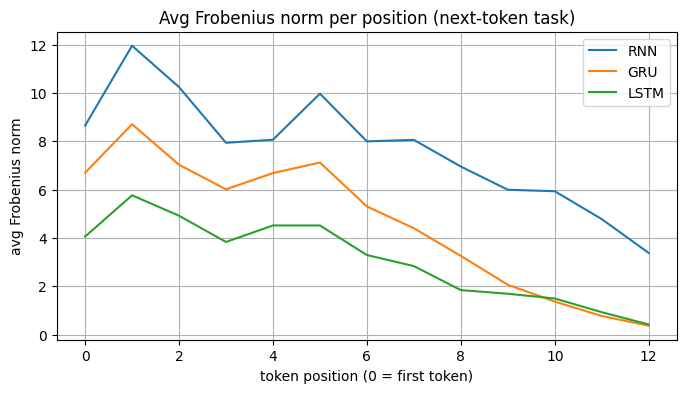

In [66]:
plot_comparison(avg_rnn_next, avg_gru_next, avg_lstm_next, title="Avg Frobenius norm per position (next-token task)")

Если бы у имён были разные длины, тензоры градиентов имели бы разный размер.
А так у всех примеров одинаковая форма, т.е. можно собрать их в один аккуратный массив.
То есть это техническое упрощение для анализа.

## __Task_10 - Multitask learning__

In [40]:
def make_next_targets(sequences, pad_id):
    y_list = []
    for seq in sequences:
        seq = seq.tolist() if not isinstance(seq, list) else seq
        y = seq[1:] + [pad_id]
        y_list.append(y)
    return np.array(y_list, dtype=np.int64)

In [41]:
y_train_next = make_next_targets(X_train, pad_id=token2id[" "])
y_val_next   = make_next_targets(X_val,   pad_id=token2id[" "])
y_test_next  = make_next_targets(X_test,  pad_id=token2id[" "])

In [42]:
class MultiTaskDataset(torch.utils.data.Dataset):
    def __init__(self, X, y_gender, y_next):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y_gender = torch.tensor(y_gender.values, dtype=torch.float32)
        self.y_next = torch.tensor(y_next, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y_gender[idx], self.y_next[idx]

In [43]:
train_ds = MultiTaskDataset(X_train, y_train, y_train_next)
val_ds   = MultiTaskDataset(X_val,   y_val,   y_val_next)
test_ds  = MultiTaskDataset(X_test,  y_test,  y_test_next)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=64)
test_loader  = DataLoader(test_ds, batch_size=64)

In [44]:
def train_multitask(model, train_loader, val_loader, optimizer, n_epochs=10, device="cpu"):
    history = {"train_next": [], "train_gender": [],
               "val_next": [], "val_gender": []}

    for epoch in range(n_epochs):
        model.train()
        train_loss_next, train_loss_gender = 0, 0

        for X, y_gender, y_next in train_loader:
            X, y_gender, y_next = X.to(device), y_gender.to(device), y_next.to(device)

            optimizer.zero_grad()
            token_logits, gender_prob, _ = model(X)

            token_logits_flat = token_logits.view(-1, token_logits.size(-1))
            y_next_flat = y_next.view(-1)
            l_next = loss_next(token_logits_flat, y_next_flat)

            l_gender = loss_gender(gender_prob.squeeze(), y_gender)

            loss = l_next + l_gender
            loss.backward()
            optimizer.step()

            train_loss_next += l_next.item()
            train_loss_gender += l_gender.item()

        model.eval()
        val_loss_next, val_loss_gender = 0, 0
        with torch.no_grad():
            for X, y_gender, y_next in val_loader:
                X, y_gender, y_next = X.to(device), y_gender.to(device), y_next.to(device)
                token_logits, gender_prob, _ = model(X)

                token_logits_flat = token_logits.view(-1, token_logits.size(-1))
                y_next_flat = y_next.view(-1)
                l_next = loss_next(token_logits_flat, y_next_flat)
                l_gender = loss_gender(gender_prob.squeeze(), y_gender)

                val_loss_next += l_next.item()
                val_loss_gender += l_gender.item()

        history["train_next"].append(train_loss_next/len(train_loader))
        history["train_gender"].append(train_loss_gender/len(train_loader))
        history["val_next"].append(val_loss_next/len(val_loader))
        history["val_gender"].append(val_loss_gender/len(val_loader))

        print(f"Epoch {epoch+1}/{n_epochs} | "
              f"Train next: {history['train_next'][-1]:.4f}, "
              f"Train gender: {history['train_gender'][-1]:.4f}, "
              f"Val next: {history['val_next'][-1]:.4f}, "
              f"Val gender: {history['val_gender'][-1]:.4f}")

    return history

In [45]:
def plot_history(history):
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(history["train_next"], label="train")
    plt.plot(history["val_next"], label="val")
    plt.title("Next-token loss")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history["train_gender"], label="train")
    plt.plot(history["val_gender"], label="val")
    plt.title("Gender loss")
    plt.legend()

    plt.show()

In [50]:
def generate_name(model, max_len=20, temperature=1.0):
    model.eval()
    x = torch.tensor([[token2id["<SOS>"]]], dtype=torch.long).to(next(model.parameters()).device)
    name = []
    with torch.no_grad():
        for _ in range(max_len):
            token_logits, _, _ = model(x)
            probs = torch.softmax(token_logits[0, -1] / temperature, dim=-1)
            next_token = torch.multinomial(probs, 1).item()
            if next_token == token2id["<EOS>"]:
                break
            name.append(next_token)
            x = torch.cat([x, torch.tensor([[next_token]], device=x.device)], dim=1)
    inv_vocab = {v:k for k,v in token2id.items()}
    return "".join(inv_vocab[t] for t in name)

In [47]:
def evaluate_gender_auc(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X, y_gender, _ in loader:
            X, y_gender = X.to(device), y_gender.to(device)
            _, gender_prob, _ = model(X)
            all_preds.extend(gender_prob.squeeze().cpu().numpy())
            all_labels.extend(y_gender.cpu().numpy())
    return roc_auc_score(all_labels, all_preds)

Epoch 1/10 | Train next: 2.8815, Train gender: 0.6956, Val next: 2.5896, Val gender: 0.6936
Epoch 2/10 | Train next: 2.5436, Train gender: 0.6929, Val next: 2.4491, Val gender: 0.6931
Epoch 3/10 | Train next: 2.4395, Train gender: 0.6686, Val next: 2.3725, Val gender: 0.5595
Epoch 4/10 | Train next: 2.3888, Train gender: 0.5335, Val next: 2.3230, Val gender: 0.4735
Epoch 5/10 | Train next: 2.3557, Train gender: 0.4907, Val next: 2.2972, Val gender: 0.4600
Epoch 6/10 | Train next: 2.3372, Train gender: 0.4715, Val next: 2.2773, Val gender: 0.4548
Epoch 7/10 | Train next: 2.3170, Train gender: 0.4596, Val next: 2.2654, Val gender: 0.4095
Epoch 8/10 | Train next: 2.3065, Train gender: 0.4553, Val next: 2.2523, Val gender: 0.4120
Epoch 9/10 | Train next: 2.2956, Train gender: 0.4449, Val next: 2.2445, Val gender: 0.4082
Epoch 10/10 | Train next: 2.2873, Train gender: 0.4368, Val next: 2.2364, Val gender: 0.4068


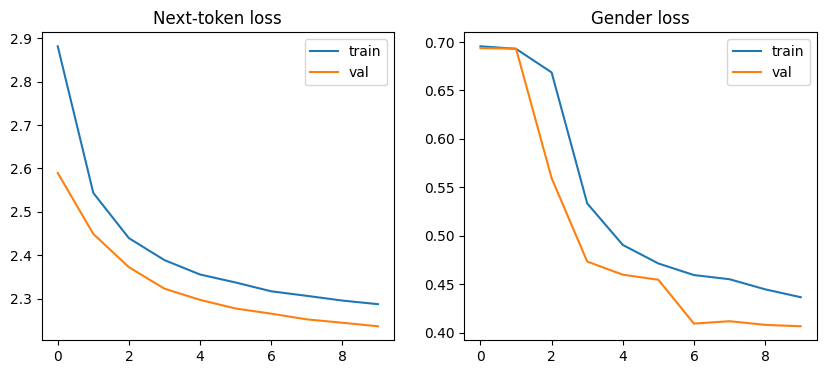

In [54]:
model = VanillaGRU(vocab_size, embedding_dim=32, hidden_dim=64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

loss_next = nn.CrossEntropyLoss(ignore_index=token2id[" "])
loss_gender = nn.BCELoss()

history = train_multitask(model, train_loader, val_loader, optimizer, n_epochs=10, device=device)
plot_history(history)

In [52]:
print("\nGenerated names:")
for _ in range(10):
    print(generate_name(model, max_len=20, temperature=1.0))


Generated names:
cavis
breba
dorie
lestty
jarhyn
jziniltuar
berisse
maich
alarl
koryle


In [53]:
auc = evaluate_gender_auc(model, test_loader)
print("\nROC AUC on test:", auc)


ROC AUC on test: 0.9178934759209749


## __Task_11 - Visualizing embeddings__